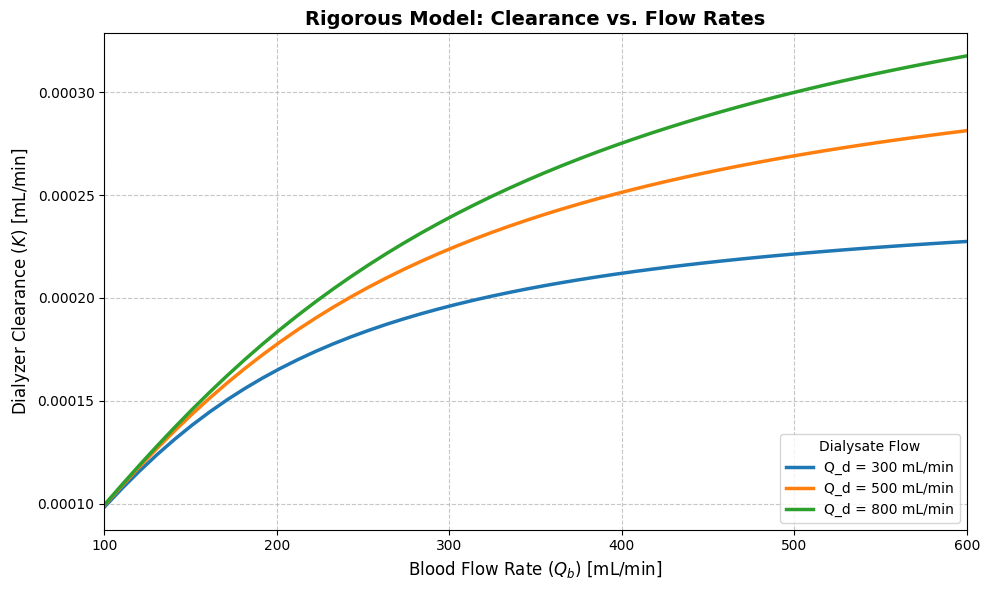

In [1]:
%reload_ext autoreload
%autoreload 2
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
# Import everything
sys.path.append('../src')
from solver import dialyzer_system
from parameters import *
from mass_transfer import calculate_area, calculate_overall_Ko

# Set up test arrays
Qb_test_ml_min = np.linspace(100, 600, 50)
Qb_test_m3_s = Qb_test_ml_min * (1e-6 / 60)
Qd_test_ml_min = [300, 500, 800]

# Calculate Area once (geometry doesn't change)
A = calculate_area()

plt.figure(figsize=(10, 6))

for Qd_ml in Qd_test_ml_min:
    Qd_m3_s = Qd_ml * (1e-6 / 60)
    clearance_results = []

    for Qb_i in Qb_test_m3_s:
        # --- THE UPGRADE: Dynamic Ko Calculation ---
        # Ko changes as fluid velocities change!
        Ko, _, _, _ = calculate_overall_Ko(Qb_i, Qd_m3_s)
        Ko_A_actual = Ko * A
        # -------------------------------------------

        initial_guesses = [1e-5, C_b_in * 0.5, C_b_in * 0.2]
        solution = fsolve(dialyzer_system, initial_guesses,
                          args=(Qb_i, Qd_m3_s, C_b_in, C_d_in, Ko_A_actual))

        N_removed = solution[0]
        clearance_ml_min = (N_removed / C_b_in) * 60
        clearance_results.append(clearance_ml_min)

    plt.plot(Qb_test_ml_min, clearance_results, label=f'Q_d = {Qd_ml} mL/min', linewidth=2.5)

plt.title('Rigorous Model: Clearance vs. Flow Rates', fontsize=14, fontweight='bold')
plt.xlabel('Blood Flow Rate ($Q_b$) [mL/min]', fontsize=12)
plt.ylabel('Dialyzer Clearance ($K$) [mL/min]', fontsize=12)
plt.legend(title="Dialysate Flow", loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(100, 600)
plt.tight_layout()
plt.show()